# Notebook 1: Data

### What we'll do here
- Describe the data sources used in the project
- Summarize the labelling workflow
- Define the four target types in the dataset
- Show example target images
- Give a snapshot of the labelled dataset

### How to run
1. Make sure `data/images` and `data/target_labels.csv` are available locally.
2. Run the notebook top-to-bottom.

### Table of Contents
- [1.1 Data Collection](#11-data-collection)
- [1.2 Labelling Strategy](#12-labelling-strategy)
- [1.3 Target Definition](#13-target-definition)
- [1.4 Dataset Snapshot](#14-dataset-snapshot)


## 1.1 Data Collection

At the start of the project, we contacted Skovshoved Skytteforening to collect real-world images of shooting targets and bullet holes.

We received around 122 images from Skovshoved Skytteforening, which served as the starting point for the dataset. To expand it, we added an open-source collection from **Roboflow Universe** (`Bullet Hole Object Detection Dataset`, 1,243 images), giving us a larger and more suitable set of images for annotation and model development.

## 1.2 Labelling Strategy

In this project, we combine manual labelling with semi-supervised model-assisted labelling. The different target types were labelled manually using a Python script, while the bullet holes were annotated through an iterative workflow with Roboflow and RF-DETR. Transfer learning allowed the model to detect most bullet holes early on, after which we manually corrected missed detections and refined the annotations.

The dataset contains four target categories. Target Types 3 and 4 are not included in training because they contain only 8 and 5 samples, respectively, making the class distribution too imbalanced. For the MVP, we therefore focus on classifying Target Type 1 and Target Type 2, while still showing how the approach could be extended to more target types with additional data.


## 1.3 Target Definition

Run the code cell below to display four example targets side by side.

### Target Summary

Target 2 is shown using a real-world example in the gallery below.

| Target | Rings | Scoring range | Visible numbers |
|---|---:|---|---:|
| Target 1 | 10 | 1-10 | 9 |
| Target 2 | 11 | 1-11 | 8 |
| Target 3 | 8 | 3-11 | 8 |
| Target 4 | 11 | 1-11 | 5 |

## 1.4 Dataset Snapshot

The current label file `data/target_labels.csv` contains **1,313 labelled samples**. The image folder contains **1,317 image files**, so **4 images** are currently unlabelled.

| Target | Samples | Share of labelled set |
|---|---:|---:|
| Target 1 | 459 | 35.0% |
| Target 2 | 841 | 64.1% |
| Target 3 | 8 | 0.6% |
| Target 4 | 5 | 0.4% |

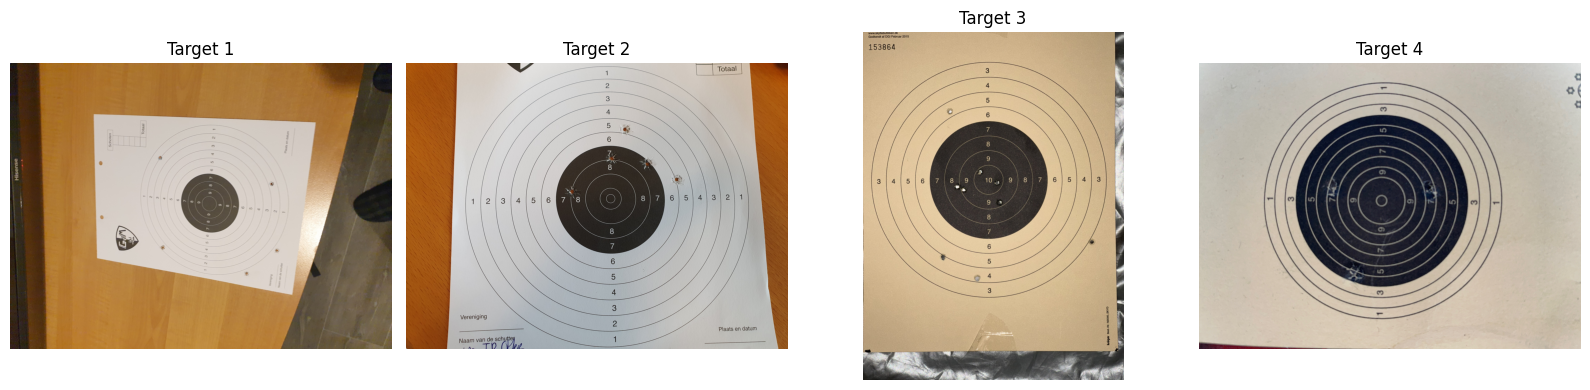

In [3]:
import matplotlib.pyplot as plt

images = [
    ("Target 1", "data/images/1_0002-13-04-2023_API_v1_jpg.rf.myJ1hGhB01ETs4YTl2MZ.jpg"),
    ("Target 2", "data/images/20200923_130907_jpg.rf.jLuXLWJV99CQUoxq2qy2.jpg"),
    ("Target 3", "data/images/IMG_1606_jpg.rf.kVbZUa3Xq25QNBgGrsWA.jpg"),
    ("Target 4", "data/images/IMG_0054_nobg_10dg_jpg.rf.vnZ4U3STQdU27E0VdbTo.jpg"),
]

fig, axes = plt.subplots(1, len(images), figsize=(16, 4))
for ax, (title, path) in zip(axes, images):
    ax.imshow(plt.imread(path))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
